# nb01 — mapping.yaml tour (Session 1)

**Exploration only — no business logic lives here** (CLAUDE.md rule 1). Everything below
renders what is already in `mapping/mapping.yaml`; the contract for that file is
`tests/test_mapping.py`.

Contents: coverage table (Checkpoint-2 buckets), per-major-group breakdown, CPI weight
treemap colored by signal coverage.

In [1]:
from pathlib import Path
import yaml
import pandas as pd

with open(Path("..") / "mapping" / "mapping.yaml") as f:
    mapping = yaml.safe_load(f)

items = mapping["cpi"]["items"]
strata = pd.DataFrame([d for d in items if d["is_stratum"]])
alt = pd.json_normalize(strata["alt"]).add_prefix("alt.")
strata = pd.concat([strata.drop(columns=["alt"]), alt], axis=1)
print(f"weights asof {mapping['cpi']['asof']} | {len(strata)} item strata, "
      f"weight sum {strata.weight_cpi_u.sum():.3f}")
strata.head(3)

weights asof 2025-12 | 204 item strata, weight sum 100.001


,name,item_code,parent_code,indent,weight_cpi_u,is_stratum,published,series_id,sa_flag,lower_level_formula,alt.alt_source,alt.alt_status,alt.plan_ref,alt.proxy_source,alt.proxy_history_start,alt.license_status,alt.confidence,alt.note
0,Flour and prepared flour mixes,SEFA01,SEFA,6,0.038,True,True,CUSR0000SEFA01,True,jevons,adobe_dpi,build,2B-B,adobe_dpi_groceries,2019.0,published_headline,low,Adobe online-grocery category; online/offline ...
1,Breakfast cereal,SEFA02,SEFA,6,0.136,True,True,CUSR0000SEFA02,True,jevons,adobe_dpi,build,2B-B,adobe_dpi_groceries,2019.0,published_headline,low,Adobe online-grocery category; online/offline ...
2,"Rice, pasta, cornmeal",SEFA03,SEFA,6,0.141,True,True,CUSR0000SEFA03,True,jevons,adobe_dpi,build,2B-B,adobe_dpi_groceries,2019.0,published_headline,low,Adobe online-grocery category; online/offline ...


In [2]:
# Checkpoint-2 coverage buckets (presentational re-labelling of yaml fields only)
def bucket(row):
    if row["alt.proxy_source"] and str(row["alt.plan_ref"]).startswith("S5"):
        return "proxy + scraped layer planned"
    if row["alt.proxy_source"]:
        return "published proxy"
    if row["alt.alt_status"] == "build":
        return "scraped layer only (no history)"
    return "unmodeled / carry consensus"

strata["bucket"] = strata.apply(bucket, axis=1)
cov = (strata.groupby("bucket")["weight_cpi_u"].agg(["sum", "count"])
       .rename(columns={"sum": "cpi_weight", "count": "n_strata"})
       .sort_values("cpi_weight", ascending=False))
cov["share_%"] = (cov["cpi_weight"] / strata["weight_cpi_u"].sum() * 100).round(1)
cov.round(2)

,cpi_weight,n_strata,share_%
bucket,,,
published proxy,90.3,198,90.3
proxy + scraped layer planned,9.7,6,9.7


In [3]:
# per-major-group coverage (major group = indent-1 ancestor)
nodes = {d["item_code"]: d for d in items if d["item_code"]}
def major_group(row):
    node, seen = row, set()
    while node["indent"] > 1 and node["parent_code"] in nodes and node["parent_code"] not in seen:
        seen.add(node["parent_code"])
        node = nodes[node["parent_code"]]
    return node["name"]

strata["major_group"] = [major_group(r) for r in strata.to_dict("records")]
pivot = (strata.pivot_table(index="major_group", columns="bucket",
                            values="weight_cpi_u", aggfunc="sum", fill_value=0.0)
         .assign(total=lambda d: d.sum(axis=1)).sort_values("total", ascending=False))
pivot.round(2)

bucket,proxy + scraped layer planned,published proxy,total
major_group,,,
Housing,0.00,44.47,44.47
Transportation,0.88,15.44,16.32
Food and beverages,5.07,9.47,14.54
Medical care,3.14,5.28,8.42
Education and communication,0.00,5.85,5.85
Recreation,0.61,4.53,5.14
Other goods and services,0.00,2.90,2.90
Apparel,0.00,2.37,2.37


Matplotlib is building the font cache; this may take a moment.


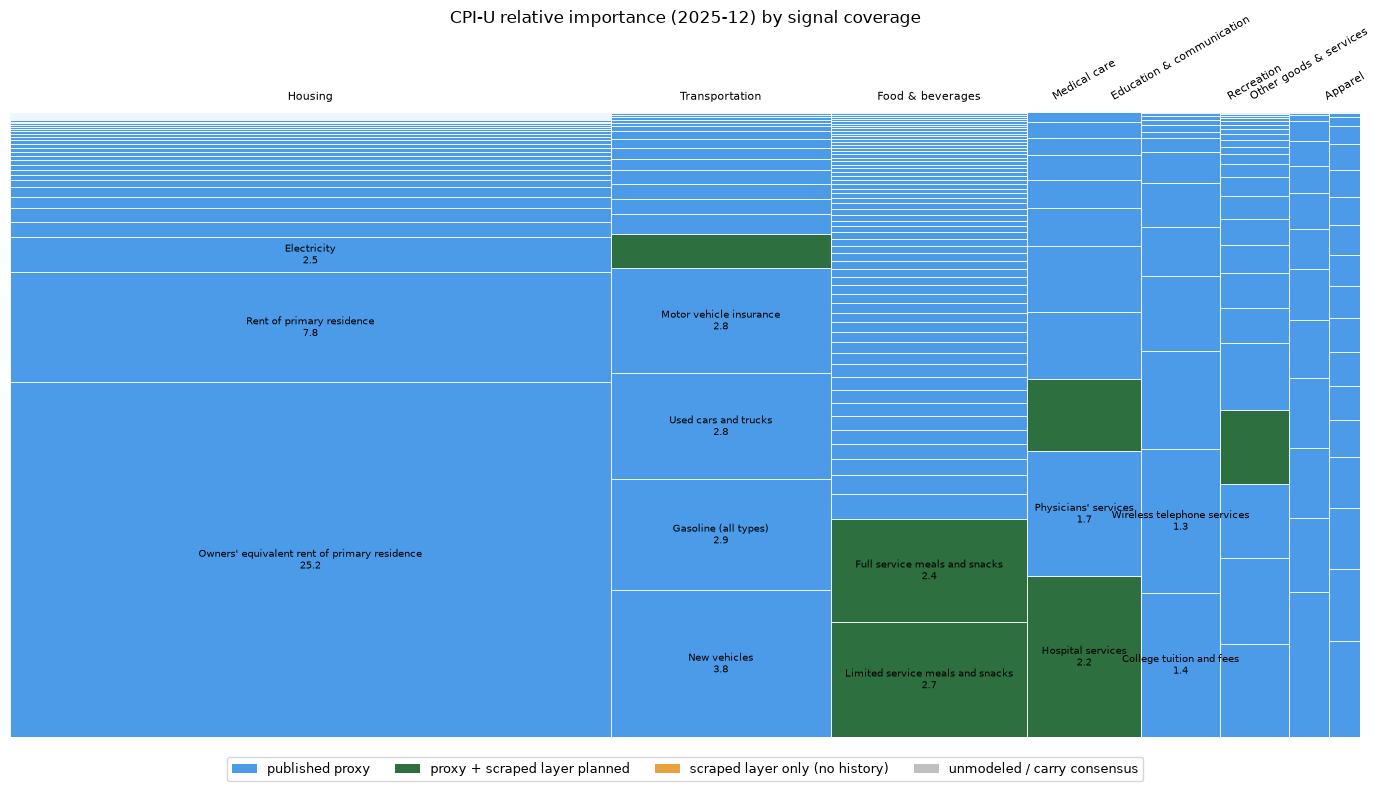

In [4]:
# CPI weight treemap (2-level mosaic: major groups sliced horizontally, strata vertically)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

COLORS = {"published proxy": "#4c9be8",
          "proxy + scraped layer planned": "#2e6f40",
          "scraped layer only (no history)": "#e8a13c",
          "unmodeled / carry consensus": "#c0c0c0"}

fig, ax = plt.subplots(figsize=(14, 8))
x = 0.0
total = strata["weight_cpi_u"].sum()
for g, gdf in sorted(strata.groupby("major_group"), key=lambda kv: -kv[1]["weight_cpi_u"].sum()):
    gw = gdf["weight_cpi_u"].sum() / total
    y = 0.0
    for _, s in gdf.sort_values("weight_cpi_u", ascending=False).iterrows():
        sh = s["weight_cpi_u"] / gdf["weight_cpi_u"].sum()
        ax.add_patch(Rectangle((x, y), gw, sh, facecolor=COLORS[s["bucket"]],
                               edgecolor="white", linewidth=0.6))
        if s["weight_cpi_u"] > 1.2 and gw > 0.04:
            ax.text(x + gw / 2, y + sh / 2, f"{s['name']}\n{s['weight_cpi_u']:.1f}",
                    ha="center", va="center", fontsize=7)
        y += sh
    ax.text(x + gw / 2, 1.015, g.replace(" and ", " & "), ha="center", va="bottom",
            fontsize=8, rotation=0 if gw > 0.09 else 30)
    x += gw
ax.set_xlim(0, 1); ax.set_ylim(0, 1.08); ax.axis("off")
handles = [Rectangle((0, 0), 1, 1, facecolor=c) for c in COLORS.values()]
ax.legend(handles, COLORS.keys(), loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=9)
ax.set_title(f"CPI-U relative importance ({mapping['cpi']['asof']}) by signal coverage", pad=28)
plt.tight_layout(); plt.show()

## Reading notes

- **Gate-1 target (≥80% covered) is short: 73.4% any-signal.** The gap is concentrated in
  infrequently-repriced services (wireless, tuition, insurance, admissions, personal care)
  where carry-consensus is arguably correct — accepted or revisited at the Session-1 review;
  see `docs/checkpoint_log_s1.md`.
- Unsampled strata (2.1 weight) carry weight but no published index; they roll up to parents.
- The 14 `confidence: low` PCE-bridge rows are enumerated in the checkpoint log for review.